In [3]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

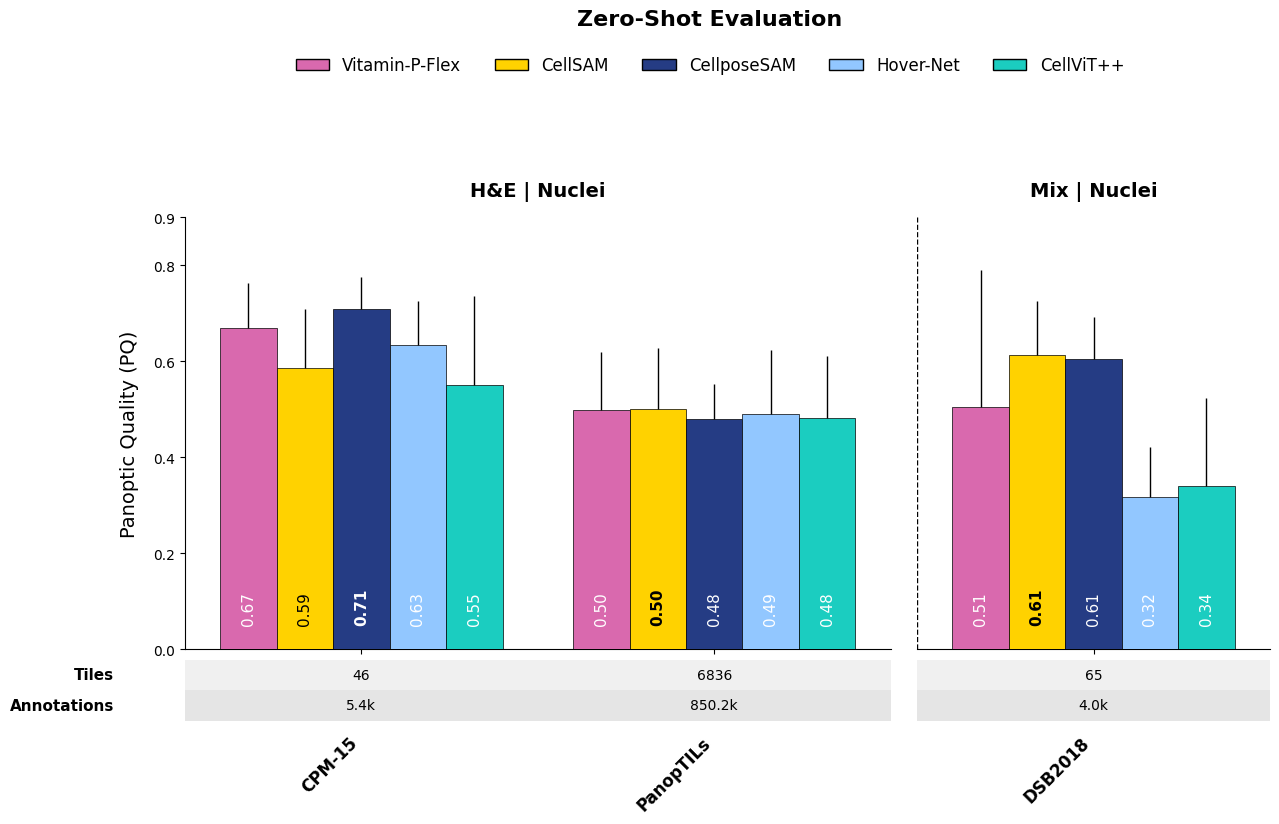

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec
from matplotlib.patches import Patch

# ---------------------------------------------------------
# NEW: SETTINGS FOR ADOBE ILLUSTRATOR COMPATIBILITY
# ---------------------------------------------------------
plt.rcParams['pdf.fonttype'] = 42  # Embeds fonts as TrueType (prevents exploding text)
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial' # Standard font for better AI compatibility
# ---------------------------------------------------------

# 1. DATA PREPARATION
models = ['Vitamin-P-Flex', 'CellSAM', 'CellposeSAM', 'Hover-Net', 'CellViT++']
datasets = ['cpm15', 'panoptils', 'dsb2018']

colors = {
    'Vitamin-P-Flex': '#d969ae',
    'CellSAM':        '#ffd200',
    'CellposeSAM':    '#253c84',
    'Hover-Net':      '#92c7ff',
    'CellViT++':      '#1bcdc0'
}

text_colors = {
    'Vitamin-P-Flex': 'white',
    'CellSAM':        'black',
    'CellposeSAM':    'white',
    'Hover-Net':      'white',
    'CellViT++':      'white'
}

# Scores (PQ) and placeholders
vit_p_scores      = [0.6684, 0.4980, 0.5055]
vit_p_std          = [0.0938, 0.1216, 0.2841]
cell_sam_scores   = [0.5852, 0.5006, 0.6134]
cell_sam_std      = [0.1234, 0.1272, 0.1120]
cellpose_scores   = [0.7084, 0.4787, 0.6057]
cellpose_std      = [0.0670, 0.0740, 0.0860]
hover_scores      = [0.6332, 0.4904, 0.3180]
hover_std         = [0.0926, 0.1337, 0.1030]
cellvit_scores    = [0.5515, 0.4822, 0.3402]
cellvit_std       = [0.1834, 0.1290, 0.1827]

all_scores = [vit_p_scores, cell_sam_scores, cellpose_scores, hover_scores, cellvit_scores]
all_stds   = [vit_p_std,    cell_sam_std,    cellpose_std,    hover_std,    cellvit_std]

tile_counts       = [46,  6836, 65]
annotation_counts = [5380,   850191,    3990]

sections_idx = {'H&E | Nuclei': [0, 1], 'Mix | Nuclei': [2]}
sections_models = {'H&E | Nuclei': models, 'Mix | Nuclei': models}

# 2. PLOT SETUP
bg_color = 'white'
width_ratios = [len(v) for v in sections_idx.values()]
fig = plt.figure(figsize=(14, 8), facecolor=bg_color)
gs  = gridspec.GridSpec(1, 2, width_ratios=width_ratios, wspace=0.05)

titles = list(sections_idx.keys())
y_min, y_max   = 0.0, 0.9
fixed_bar_width = 0.16
dataset_display_names = {'cpm15': 'CPM-15', 'panoptils': 'PanopTILs', 'dsb2018': 'DSB2018'}

# 3. PLOTTING LOOP
for i, section in enumerate(titles):
    ax = plt.subplot(gs[i])
    indices = sections_idx[section]
    section_models = sections_models[section]
    x = np.arange(len(indices))
    n_models = len(section_models)
    total_width = n_models * fixed_bar_width
    offsets = np.linspace(-total_width / 2 + fixed_bar_width / 2, total_width / 2 - fixed_bar_width / 2, n_models)

    for m_idx, model in enumerate(section_models):
        model_idx = models.index(model)
        c, txt_color = colors[model], text_colors[model]
        m_scores, m_stds = [all_scores[model_idx][j] for j in indices], [all_stds[model_idx][j] for j in indices]

        rects = ax.bar(x + offsets[m_idx], m_scores, fixed_bar_width, color=c, edgecolor='black', linewidth=0.5, zorder=3)
        ax.errorbar(x + offsets[m_idx], m_scores, yerr=[[0] * len(m_scores), m_stds], fmt='none', ecolor='black', elinewidth=1, capsize=0, zorder=4)

        for rect, val, dataset_idx in zip(rects, m_scores, indices):
            if val > 0.0:
                max_score = max([all_scores[models.index(m)][dataset_idx] for m in section_models])
                fontweight = 'bold' if (val == max_score) else 'normal'
                ax.text(rect.get_x() + rect.get_width() / 2., 0.05, f'{val:.2f}', ha='center', va='bottom', rotation=90, color=txt_color, fontsize=11, fontweight=fontweight, zorder=5)

    # Axes Formatting
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(-0.5, len(indices) - 0.5)
    ax.set_title(section, fontsize=14, pad=15, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x); ax.set_xticklabels([])

    if i > 0:
        line_left = plt.Line2D([0, 0], [0, 1], transform=ax.transAxes, color='black', linestyle='--', linewidth=1)
        ax.add_line(line_left)
        ax.spines['left'].set_visible(False); ax.set_yticks([])
    else:
        ax.set_ylabel('Panoptic Quality (PQ)', fontsize=14, labelpad=10)
        ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 0.9])

    # Table Below X-Axis
    table_y_start, row_height = -0.06, 0.07
    row_labels = ['Tiles', 'Annotations']
    for r in range(2):
        row_y = table_y_start - (r * row_height)
        bg_color_table = '#f0f0f0' if r == 0 else '#e5e5e5'
        rect_patch = plt.Rectangle((-0.5, row_y - row_height / 2), len(indices), row_height, facecolor=bg_color_table, transform=ax.get_xaxis_transform(), zorder=0, clip_on=False)
        ax.add_patch(rect_patch)
        if i == 0:
            ax.text(-0.7, row_y, row_labels[r], ha='right', va='center', transform=ax.get_xaxis_transform(), fontweight='bold', fontsize=11)

    sec_data = [[tile_counts[j] for j in indices], [annotation_counts[j] for j in indices]]
    for r in range(2):
        for idx_col, val in enumerate(sec_data[r]):
            text_val = "TBD" if (row_labels[r] == 'Annotations' and val == 0) else (f"{val/1000:.1f}k" if (row_labels[r] == 'Annotations' and val >= 1000) else str(val))
            ax.text(idx_col, table_y_start - (r * row_height), text_val, ha='center', va='center', transform=ax.get_xaxis_transform(), fontsize=10)

    # Diagonal dataset labels
    for idx_col, j in enumerate(indices):
        ax.text(idx_col, table_y_start - (1.5 * row_height) - 0.03, dataset_display_names[datasets[j]], ha='right', va='top', rotation=45, transform=ax.get_xaxis_transform(), fontsize=12, fontweight='bold')

# 4. TITLE, LEGEND & SAVE
fig.suptitle('Zero-Shot Evaluation', fontsize=16, fontweight='bold', y=1.08)
legend_elements = [Patch(facecolor=colors[m], edgecolor='k', label=m) for m in models]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=5, frameon=False, fontsize=12)

plt.subplots_adjust(bottom=0.28, top=0.82)
plt.savefig('zeroshot.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()